# Using 1D Convolutional Layers to Process Sequences

## 1 Data

In [1]:
from load_data import load_data

dataset = load_data()

single_step :
   X :
     train :  (7000, 41, 1)
     valid :  (2000, 41, 1)
     test :  (1000, 41, 1)
   Y :
     train :  (7000, 41, 10)
     valid :  (2000, 41, 10)
     test :  (1000, 41, 10)
multi_horizon :
   X :
     train :  (7000, 41, 1)
     valid :  (2000, 41, 1)
     test :  (1000, 41, 1)
   Y :
     train :  (7000, 41, 10)
     valid :  (2000, 41, 10)
     test :  (1000, 41, 10)
sequence :
   X :
     train :  (7000, 41, 1)
     valid :  (2000, 41, 1)
     test :  (1000, 41, 1)
   Y :
     train :  (7000, 41, 10)
     valid :  (2000, 41, 10)
     test :  (1000, 41, 10)


## 2 Model

### 2.1 Layer

In [2]:
None

### 2.2 Model

In [3]:
import tensorflow as tf


def mse_last_time_step(y_true: tf.Tensor, y_pred: tf.Tensor) -> tf.Tensor:
    return tf.keras.metrics.mean_squared_error(y_true[:, -1], y_pred[:, -1])

2023-02-07 06:24:01.540869: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv1D(filters=20, kernel_size=4, strides=2, padding="valid", input_shape=(None, 1)),
    tf.keras.layers.LSTM(20, return_sequences=True),
    tf.keras.layers.LSTM(20, return_sequences=True),
    tf.keras.layers.Dense(10)
])
model.compile(optimizer="adam", loss="mse", metrics=mse_last_time_step)
model.summary()

2023-02-07 06:24:03.384473: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-02-07 06:24:03.424358: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-02-07 06:24:03.425016: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-02-07 06:24:03.425800: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropri

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, None, 20)          100       
                                                                 
 lstm (LSTM)                 (None, None, 20)          3280      
                                                                 
 lstm_1 (LSTM)               (None, None, 20)          3280      
                                                                 
 dense (Dense)               (None, None, 10)          210       
                                                                 
Total params: 6,870
Trainable params: 6,870
Non-trainable params: 0
_________________________________________________________________


## 3 Training

In [6]:
import time
from pathlib import Path

epochs = 100
root_logdir = Path().absolute() / "logs"
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
tensorboard_cb = tf.keras.callbacks.TensorBoard(root_logdir / time.strftime("%Y_%m_%d-%H_%M_%S_rnn_sts"))

%load_ext tensorboard
%tensorboard --logdir=./ logs --port=6006

Launching TensorBoard...

In [7]:
history = model.fit(
    dataset["sequence"]["X"]["train"], dataset["sequence"]["Y"]["train"][:, 3::2],
    validation_data=(dataset["sequence"]["X"]["valid"], dataset["sequence"]["Y"]["valid"][:, 3::2]),
    epochs=epochs,
    callbacks=[early_stopping_cb, tensorboard_cb]
)

Epoch 1/100


2023-02-07 06:24:17.041447: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8401
2023-02-07 06:24:17.515120: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2023-02-07 06:24:17.515796: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2023-02-07 06:24:17.515820: W tensorflow/stream_executor/gpu/asm_compiler.cc:80] Couldn't get ptxas version string: INTERNAL: Couldn't invoke ptxas --version
2023-02-07 06:24:17.516432: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2023-02-07 06:24:17.516488: W tensorflow/stream_executor/gpu/redzone_allocator.cc:314] INTERNAL: Failed to launch ptxas
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This message will be only logged once.


219/219 [==============================] - 6s 13ms/step - loss: 0.0632 - mse_last_time_step: 0.0591 - val_loss: 0.0339 - val_mse_last_time_step: 0.0326
Epoch 2/100
219/219 [==============================] - 2s 9ms/step - loss: 0.0268 - mse_last_time_step: 0.0252 - val_loss: 0.0208 - val_mse_last_time_step: 0.0182
Epoch 3/100
219/219 [==============================] - 2s 9ms/step - loss: 0.0159 - mse_last_time_step: 0.0122 - val_loss: 0.0131 - val_mse_last_time_step: 0.0091
Epoch 4/100
219/219 [==============================] - 2s 9ms/step - loss: 0.0114 - mse_last_time_step: 0.0077 - val_loss: 0.0103 - val_mse_last_time_step: 0.0068
Epoch 5/100
219/219 [==============================] - 2s 9ms/step - loss: 0.0095 - mse_last_time_step: 0.0062 - val_loss: 0.0089 - val_mse_last_time_step: 0.0058
Epoch 6/100
219/219 [==============================] - 2s 9ms/step - loss: 0.0084 - mse_last_time_step: 0.0054 - val_loss: 0.0079 - val_mse_last_time_step: 0.0051
Epoch 7/100
219/219 [============

In [8]:
# Save model
dir_models = Path() / "models"
model.save(dir_models / "model_cnn_lstm")

INFO:tensorflow:Assets written to: models/model_cnn_lstm/assets


INFO:tensorflow:Assets written to: models/model_cnn_lstm/assets


## 4 Evaluation

In [9]:
import numpy as np

i_ts = 1
x = dataset["sequence"]["X"]["test"][i_ts, :]
y_true = dataset["sequence"]["Y"]["test"][i_ts][-1, :]
y_pred = model.predict(x[np.newaxis, :, :])[0, -1]

1/1 [==============================] - 1s 665ms/step


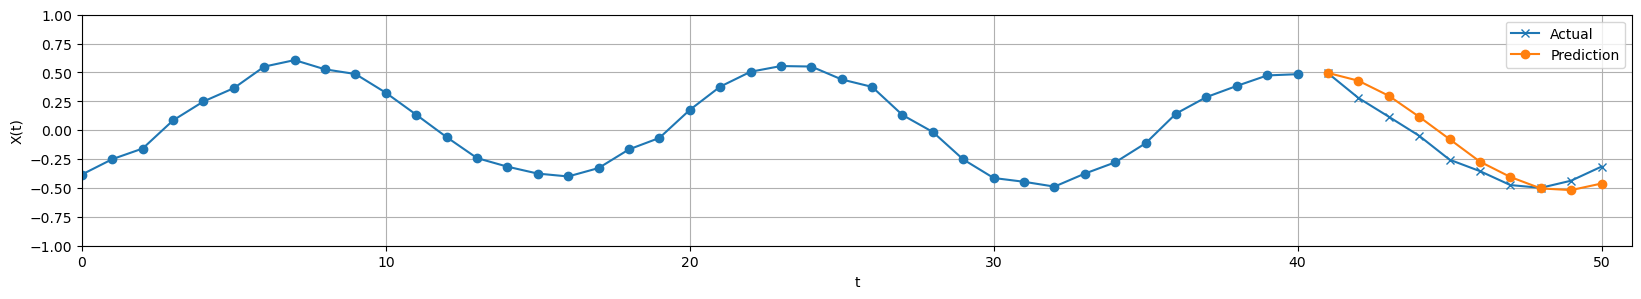

In [10]:
from plot import plot

plot(series=x[:, 0], y_true=y_true, y_pred=y_pred)